<a href="https://colab.research.google.com/github/GonzVerse/ACI216.jl/blob/main/jarvis-tools-notebooks/Fast_Melt_Quench.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Cloning into 'alignn'...
remote: Enumerating objects: 5376, done.
remote: Counting objects: 100% (578/578), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 5376 (delta 547), reused 518 (delta 505), pack-reused 4798 (from 1)
Receiving objects: 100% (5376/5376), 155.16 MiB | 17.22 MiB/s, done.
Resolving deltas: 100% (3279/3279), done.
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
Switched to a new branch 'develop'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 228.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 207.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 349.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 372.2 MB/s eta 0:00:00


In [2]:
# This cell is intentionally left blank after consolidating installation steps into the previous cell.

In [2]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


In [4]:
# %%time
# import os
# !pip install uv
# !uv venv .venv --python 3.11
# !source .venv/bin/activate
# !pip install -q alignn
# !pip uninstall dgl -y
# !uv pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html
# # !git clone https://github.com/usnistgov/alignn.git
# # os.chdir("alignn")
# # !git checkout redw
# # !uv pip install -q -e .


In [15]:
#https://linuxtut.com/en/dd9c3ed201ce2eac4757/
import time
import numpy as np
from ase import units
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.io.trajectory import Trajectory
from ase.geometry.analysis import Analysis
from jarvis.core.atoms import Atoms, get_supercell_dims
from alignn.ff.ff import AlignnAtomwiseCalculator
from jarvis.db.figshare import data, get_jid_data
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
calc = AlignnAtomwiseCalculator(device=device)

cuda
dir_path /content/alignn/alignn/ff/v12.2.2024_dft_3d_307k


In [6]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [7]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [8]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# The above lines are typically run once to set up condacolab and restart the runtime.
# After restart, if condacolab is active, it modifies the environment.
# The subsequent installation steps should be run to install packages within the condacolab environment.

# Check if condacolab is active before proceeding with further installations
import os
if 'CONDA_PREFIX' not in os.environ:
    print("Condacolab not active. Re-running condacolab.install().")
    !pip install -q condacolab
    import condacolab
    condacolab.install()
else:
    print("Condacolab is active. Proceeding with installations.")

Condacolab not active. Re-running condacolab.install().
✨🍰✨ Everything looks OK!


In [9]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: dgl 2.4.0+cu124
Uninstalling dgl-2.4.0+cu124:
  Successfully uninstalled dgl-2.4.0+cu124
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: alignn 2025.11.1
Uninstalling alignn-2025.11.1:
  Successfully uninstalled alignn-2025.11.1
Already on 'develop'
Your branch is up to date with 'origin/develop'.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 316.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 121.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for 

In [10]:
#https://linuxtut.com/en/dd9c3ed201ce2eac4757/
import time
import numpy as np
from ase import units
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.io.trajectory import Trajectory
from ase.geometry.analysis import Analysis
from jarvis.core.atoms import Atoms, get_supercell_dims
from alignn.ff.ff import AlignnAtomwiseCalculator
from jarvis.db.figshare import data, get_jid_data
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
calc = AlignnAtomwiseCalculator(device=device)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
cuda
dir_path /content/alignn/alignn/ff/v12.2.2024_dft_3d_307k


100%|██████████| 549k/549k [00:00<00:00, 751kiB/s]


In [11]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# The above lines are typically run once to set up condacolab and restart the runtime.
# After restart, if condacolab is active, it modifies the environment.
# The subsequent installation steps should be run to install packages within the condacolab environment.

# Check if condacolab is active before proceeding with further installations
import os
if 'CONDA_PREFIX' not in os.environ:
    print("Condacolab not active. Re-running condacolab.install().")
    !pip install -q condacolab
    import condacolab
    condacolab.install()
else:
    print("Condacolab is active. Proceeding with installations.")

Condacolab not active. Re-running condacolab.install().
✨🍰✨ Everything looks OK!


In [12]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# The above lines are typically run once to set up condacolab and restart the runtime.
# After restart, if condacolab is active, it modifies the environment.
# The subsequent installation steps should be run to install packages within the condacolab environment.

# Check if condacolab is active before proceeding with further installations
import os
if 'CONDA_PREFIX' not in os.environ:
    print("Condacolab not active. Re-running condacolab.install().")
    !pip install -q condacolab
    import condacolab
    condacolab.install()
else:
    print("Condacolab is active. Proceeding with installations.")

Condacolab not active. Re-running condacolab.install().
✨🍰✨ Everything looks OK!


In [13]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# The above lines are typically run once to set up condacolab and restart the runtime.
# After restart, if condacolab is active, it modifies the environment.
# The subsequent installation steps should be run to install packages within the condacolab environment.

# Check if condacolab is active before proceeding with further installations
import os
if 'CONDA_PREFIX' not in os.environ:
    print("Condacolab not active. Re-running condacolab.install().")
    !pip install -q condacolab
    import condacolab
    condacolab.install()
else:
    print("Condacolab is active. Proceeding with installations.")

Condacolab not active. Re-running condacolab.install().
✨🍰✨ Everything looks OK!


In [14]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# The above lines are typically run once to set up condacolab and restart the runtime.
# After restart, if condacolab is active, it modifies the environment.
# The subsequent installation steps should be run to install packages within the condacolab environment.

# Check if condacolab is active before proceeding with further installations
import os
if 'CONDA_PREFIX' not in os.environ:
    print("Condacolab not active. Re-running condacolab.install().")
    !pip install -q condacolab
    import condacolab
    condacolab.install()
else:
    print("Condacolab is active. Proceeding with installations.")

Condacolab not active. Re-running condacolab.install().
✨🍰✨ Everything looks OK!


In [2]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: dgl 2.4.0+cu124
Uninstalling dgl-2.4.0+cu124:
  Successfully uninstalled dgl-2.4.0+cu124
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: alignn 2025.11.1
Uninstalling alignn-2025.11.1:
  Successfully uninstalled alignn-2025.11.1
Already on 'develop'
Your branch is up to date with 'origin/develop'.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 278.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 278.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 331.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for 

In [3]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: dgl 2.4.0+cu124
Uninstalling dgl-2.4.0+cu124:
  Successfully uninstalled dgl-2.4.0+cu124
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: alignn 2025.11.1
Uninstalling alignn-2025.11.1:
  Successfully uninstalled alignn-2025.11.1
Already on 'develop'
Your branch is up to date with 'origin/develop'.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 326.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 278.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 481.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for 

In [5]:
#https://linuxtut.com/en/dd9c3ed201ce2eac4757/
import time
import numpy as np
from ase import units
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.io.trajectory import Trajectory
from ase.geometry.analysis import Analysis
from jarvis.core.atoms import Atoms, get_supercell_dims
from alignn.ff.ff import AlignnAtomwiseCalculator
from jarvis.db.figshare import data, get_jid_data
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
calc = AlignnAtomwiseCalculator(device=device)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [4]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: dgl 2.4.0+cu124
Uninstalling dgl-2.4.0+cu124:
  Successfully uninstalled dgl-2.4.0+cu124
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: alignn 2025.11.1
Uninstalling alignn-2025.11.1:
  Successfully uninstalled alignn-2025.11.1
Already on 'develop'
Your branch is up to date with 'origin/develop'.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 216.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for 

In [5]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

Found existing installation: dgl 2.4.0+cu124
Uninstalling dgl-2.4.0+cu124:
  Successfully uninstalled dgl-2.4.0+cu124
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: alignn 2025.11.1
Uninstalling alignn-2025.11.1:
  Successfully uninstalled alignn-2025.11.1
Already on 'develop'
Your branch is up to date with 'origin/develop'.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 MB 241.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 356.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 443.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for 

In [16]:
#https://linuxtut.com/en/dd9c3ed201ce2eac4757/
import time
import numpy as np
from ase import units
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.io.trajectory import Trajectory
from ase.geometry.analysis import Analysis
from jarvis.core.atoms import Atoms, get_supercell_dims
from alignn.ff.ff import AlignnAtomwiseCalculator
from jarvis.db.figshare import data, get_jid_data
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
calc = AlignnAtomwiseCalculator(device=device)

cuda
dir_path /content/alignn/alignn/ff/v12.2.2024_dft_3d_307k


In [ ]:
%%time
import os

# Ensure clean state for problematic packages before fresh installation
!pip uninstall -y dgl numpy scipy alignn

os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop

# Allow conda/pip to manage numpy/scipy versions to avoid conflicts.
# !pip install -q numpy==1.26.4 scipy==1.13.1

# Then install dgl which might depend on numpy/scipy
# Note: The torch version conflict for torchvision/torchaudio remains, but is not the direct cause of the current numpy error.
# We proceed with the specified dgl wheel.
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html

# Finally, install alignn in editable mode
!pip install -q -e .

os.chdir('/content')

In [17]:
#https://linuxtut.com/en/dd9c3ed201ce2eac4757/
import time
import numpy as np
from ase import units
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.io.trajectory import Trajectory
from ase.geometry.analysis import Analysis
from jarvis.core.atoms import Atoms, get_supercell_dims
from alignn.ff.ff import AlignnAtomwiseCalculator
from jarvis.db.figshare import data, get_jid_data
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
calc = AlignnAtomwiseCalculator(device=device)

cuda
dir_path /content/alignn/alignn/ff/v12.2.2024_dft_3d_307k


Silicon

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 40.8M/40.8M [00:03<00:00, 10.4MiB/s]


Loading the zipfile...
Loading completed.


/usr/local/lib/python3.12/dist-packages/jarvis/analysis/structure/spacegroup.py:315: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  n = self._dataset["number"]
/tmp/ipykernel_2347/39872346.py:12: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(calc)
/usr/local/lib/python3.12/dist-packages/ase/md/md.py:54: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


System
1.0
10.98726 0.0 0.0
0.0 10.98726 0.0
0.0 0.0 10.98726
Si 
64 
direct
0.125 0.375 0.125 Si
0.125 0.375 0.625 Si
0.125 0.8750000000000001 0.125 Si
0.125 0.8750000000000001 0.625 Si
0.625 0.375 0.125 Si
0.625 0.375 0.625 Si
0.625 0.8750000000000001 0.125 Si
0.625 0.8750000000000001 0.625 Si
0.0 0.0 0.25 Si
0.0 0.0 0.75 Si
0.0 0.5 0.25 Si
0.0 0.5 0.75 Si
0.5 0.0 0.25 Si
0.5 0.0 0.75 Si
0.5 0.5 0.25 Si
0.5 0.5 0.75 Si
0.125 0.125 0.375 Si
0.125 0.125 0.8750000000000001 Si
0.125 0.625 0.375 Si
0.125 0.625 0.8750000000000001 Si
0.625 0.125 0.375 Si
0.625 0.125 0.8750000000000001 Si
0.625 0.625 0.375 Si
0.625 0.625 0.8750000000000001 Si
0.0 0.25 0.0 Si
0.0 0.25 0.5 Si
0.0 0.75 0.0 Si
0.0 0.75 0.5 Si
0.5 0.25 0.0 Si
0.5 0.25 0.5 Si
0.5 0.75 0.0 Si
0.5 0.75 0.5 Si
0.375 0.375 0.375 Si
0.375 0.375 0.8750000000000001 Si
0.375 0.8750000000000001 0.375 Si
0.375 0.8750000000000001 0.8750000000000001 Si
0.8750000000000001 0.375 0.375 Si
0.8750000000000001 0.375 0.8750000000000001 Si
0.87500000

/content/alignn/alignn/ff/calculators.py:304: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  torch.tensor(atoms.cell)


Streaming output truncated to the last 5000 lines.
        (2): SiLU()
      )
    )
  )
  (angle_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=40, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
  )
  (alignn_layers): ModuleList(
    (0-1): 2 x ALIGNNConv(
      (node_update): EdgeGatedGraphConv(
        (src_gate): Linear(in_features=64, out_features=64, bias=True)
        (dst_gate): Linear(in_features=64, out_features=64, bias=True)
        (edge_gate): Linear(in_features=64, out_features=64, bias=True)
        (bn_edges): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (src_update): Linear(in_features=64,

MovieWriter imagemagick unavailable; using Pillow instead.


Time taken 536.1779406070709
System
1.0
10.98726 0.0 0.0
0.0 10.98726 0.0
0.0 0.0 10.98726
Si 
64 
direct
-0.154827735008215 1.3934185485047361 0.17457384892246638 Si
0.006297854765919992 0.3947920120826523 0.8263210693679854 Si
-0.07223449195540078 1.2210705312117898 0.2682081834674737 Si
0.43924173887757806 0.8108296307444063 0.893170814470661 Si
0.39785500773396515 0.6804421688125346 0.06182017475348101 Si
0.6137358751693429 0.15286870383411158 1.05228696003497 Si
0.5528751921625527 0.5304823388192627 0.08230330794530619 Si
0.5642742406887844 0.6916036841897488 1.4231660259565309 Si
-0.21988542947801543 -0.06759755337304581 0.4820099345885696 Si
-0.1538977844840288 0.29289926108302194 0.48258318876464235 Si
-0.5830940833051985 0.06681364771361956 0.3248181930717968 Si
0.6861442705378387 0.5530972286751847 0.9142954981640806 Si
0.33553080751457565 -0.015574913096353631 -0.03289753376444161 Si
1.409428610555529 -0.3047703302018732 0.7177009036051046 Si
0.47990087573208984 0.3411928146

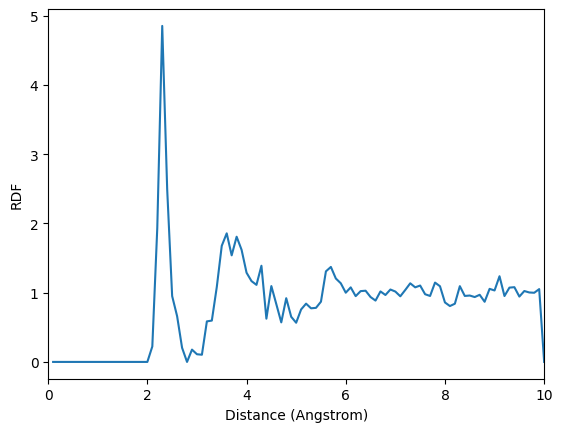

In [18]:
def get_atoms(jid):
    dat = get_jid_data(jid=jid, dataset="dft_3d")
    atoms= Atoms.from_dict(dat["atoms"]).get_conventional_atoms
    dim = get_supercell_dims(atoms,enforce_c_size=10)
    atoms = atoms.make_supercell([dim[0], dim[1], dim[2]])
    print(atoms)
    return atoms.ase_converter()

jid='JVASP-41'
jid='JVASP-1002' # Silicon
atoms = get_atoms(jid)
atoms.set_calculator(calc)
t1=time.time()

dt = 1 * units.fs

temp0, nsteps0 = 5500, 1000
temp1, nsteps1 = 300, 2000
taut = 20*units.fs

MaxwellBoltzmannDistribution(atoms, temp0*units.kB)
dyn = NVTBerendsen(atoms, dt, temp0, taut=taut, trajectory='md.traj')
def myprint():
    print(f'time={dyn.get_time() / units.fs: 5.0f} fs ' + \
          f'T={atoms.get_temperature(): 3.0f} K')
dyn.attach(myprint, interval=20)
dyn.run(nsteps0)

#Raise the temperature
dyn.set_temperature(temp1)
dyn.run(nsteps1)


traj =  Trajectory('md.traj')

fig, ax = plt.subplots(1, 3, figsize=(9,3), tight_layout=True)

t = np.arange(nsteps0+nsteps1+1) * dt
temp = [atoms.get_temperature() for atoms in traj]

nframes = 20



t2=time.time()
print('Time taken', t2-t1)
def update(iframe):
    idx = int((nsteps0+nsteps1)*iframe/nframes)

    ax[0].clear()
    ax[0].set_title('Temperature')
    ax[0].set_xlabel('time (fs)')
    ax[0].set_ylabel('T (K)')
    ax[0].plot(t, temp)
    ax[0].plot(t[idx], temp[idx], marker='X', markersize=10)

    ax[1].clear()
    ax[1].set_title('Structure')
    ax[1].axis('off')
    plot_atoms(traj[idx], ax=ax[1], rotation='45x,45y')

    distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]
    ax[2].clear()
    ax[2].set_title('RDF')
    ax[2].set_ylim((0,10))
    ax[2].set_xlabel('distance (A))')
    ax[2].set_ylabel('distribution')
    ax[2].plot(distance, distribution, color='darkblue')
ani = FuncAnimation(fig, update, np.arange(nframes), blit=False, interval=250.)
ani.save('ani_si_2k.gif', writer="imagemagick")
plt.close()

traj = Trajectory('md.traj')
atoms=ase_to_atoms(traj[-1])
print(atoms)
dists=[]
for i in atoms.get_all_neighbors(r=10):
    for j in i:
      dists.append(j[2])
dists=np.array(dists)
hist, bins = np.histogram(dists, bins=np.arange(0.1, 10.2, 0.1))
number_density = atoms.num_atoms / atoms.volume
shell_vol = (
            4.0
            / 3.0
            * np.pi
            * (np.power(bins[1:], 3) - np.power(bins[:-1], 3))
        )
rdf = (
            hist / shell_vol / number_density / atoms.num_atoms
        )
plt.plot(bins[:-1], rdf)
plt.xlim([0,10])
plt.xlabel('Distance (Angstrom)')
plt.ylabel('RDF')
# plt.savefig('rdf.png')
# plt.close()
plt.show()


In [19]:
!ls -altr

total 10940
drwxr-xr-x 4 root root     4096 Feb  6 14:31 .config
drwxr-xr-x 1 root root     4096 Feb  6 14:31 sample_data
drwxr-xr-x 1 root root     4096 Mar 14 01:57 ..
drwxr-xr-x 6 root root     4096 Mar 14 02:04 alignn
-rw-r--r-- 1 root root    21477 Mar 14 02:05 condacolab_install.log
-rw-r--r-- 1 root root 10643271 Mar 14 02:46 md.traj
drwxr-xr-x 1 root root     4096 Mar 14 02:46 .
-rw-r--r-- 1 root root   506118 Mar 14 02:46 ani_si_2k.gif


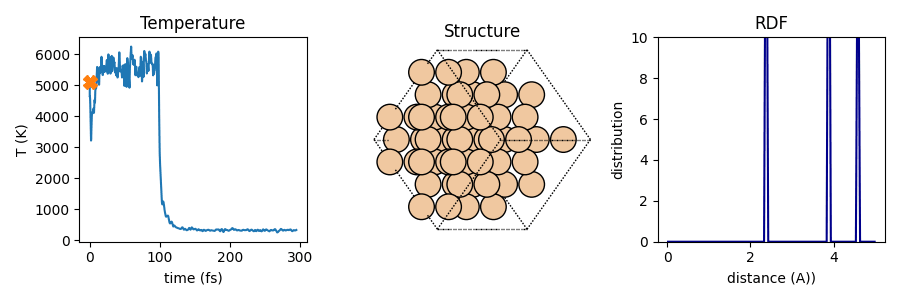

In [20]:
from IPython.display import Image, display

display(Image(filename='ani_si_2k.gif'))


Al2O3

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
System
1.0
7.20522 -12.47982 0.0
7.20522 12.47982 0.0
0.0 0.0 13.09743
Al O 
108 162 
direct
0.11111111111111115 0.22222222222222218 0.31440267807851674 Al
0.11111111111111119 0.5555555555555555 0.31440267807851674 Al
0.1111111111111112 0.8888888888888887 0.31440267807851674 Al
0.4444444444444445 0.2222222222222222 0.31440267807851674 Al
0.4444444444444445 0.5555555555555555 0.31440267807851674 Al
0.44444444444444453 0.8888888888888888 0.31440267807851674 Al
0.7777777777777778 0.22222222222222215 0.31440267807851674 Al
0.7777777777777778 0.5555555555555556 0.31440267807851674 Al
0.7777777777777778 0.8888888888888887 0.31440267807851674 Al
0.22222222222222224 0.1111111111111111 0.1855973219214833 Al
0.22222222222222227 0.4444444444444444 0.1855973219214833 Al
0.22222222222222227 0.7777777777777777 0.18

/usr/local/lib/python3.12/dist-packages/jarvis/analysis/structure/spacegroup.py:315: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  n = self._dataset["number"]
<timed exec>:12: FutureWarning: Please use atoms.calc = calc
/usr/local/lib/python3.12/dist-packages/ase/md/md.py:54: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


Streaming output truncated to the last 5000 lines.
        (2): SiLU()
      )
    )
  )
  (angle_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=40, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
  )
  (alignn_layers): ModuleList(
    (0-1): 2 x ALIGNNConv(
      (node_update): EdgeGatedGraphConv(
        (src_gate): Linear(in_features=64, out_features=64, bias=True)
        (dst_gate): Linear(in_features=64, out_features=64, bias=True)
        (edge_gate): Linear(in_features=64, out_features=64, bias=True)
        (bn_edges): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (src_update): Linear(in_features=64,

MovieWriter imagemagick unavailable; using Pillow instead.


Time taken 3544.919285774231
System
1.0
7.20522 -12.47982 0.0
7.20522 12.47982 0.0
0.0 0.0 13.09743
Al O 
108 162 
direct
0.10623956125288335 0.2290479864266245 0.2057702589018525 Al
0.09945122722787741 0.5784961144339424 0.32895314037859236 Al
0.14305653149583106 0.9049944489383195 0.311705015591308 Al
0.21796329087910796 0.1135090398059437 0.38392187563257346 Al
0.4179925804215243 0.5452199183946347 0.19790790885922543 Al
0.4491740262851492 0.8898149420588575 0.18547675789802306 Al
0.7717836083237909 0.21074291415802004 0.32272650712585743 Al
0.7938080556403982 0.6008228054799234 0.29542090287923567 Al
0.7977343087654952 0.8972674934947538 0.3305897693762215 Al
0.2647274144254495 0.11926929608976525 0.17179760031378294 Al
0.22403241880112248 0.4813736548748364 0.30645394204717025 Al
0.21350800405278236 0.7753268349559216 0.17879991538695092 Al
0.5763641804800741 0.13089001547250392 0.20262730411231217 Al
0.5651312155245047 0.4229674705840718 0.1817801709065915 Al
0.5613822407559892 0

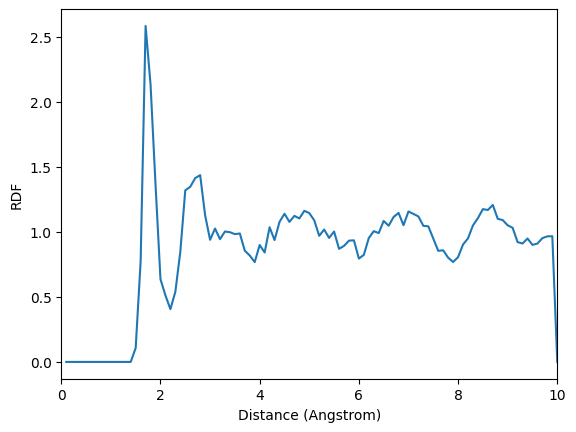

CPU times: user 52min 33s, sys: 21min 58s, total: 1h 14min 31s
Wall time: 59min 52s


In [21]:
%%time
def get_atoms(jid):
    dat = get_jid_data(jid=jid, dataset="dft_3d")
    atoms= Atoms.from_dict(dat["atoms"]).get_conventional_atoms
    dim = get_supercell_dims(atoms,enforce_c_size=10)
    atoms = atoms.make_supercell([dim[0], dim[1], dim[2]])
    print(atoms)
    return atoms.ase_converter()

jid='JVASP-32'
#jid='JVASP-1002'
atoms = get_atoms(jid)
atoms.set_calculator(calc)
t1=time.time()

dt = 1 * units.fs

temp0, nsteps0 = 5500, 1000
temp1, nsteps1 = 300, 2000
taut = 20*units.fs

MaxwellBoltzmannDistribution(atoms, temp0*units.kB)
dyn = NVTBerendsen(atoms, dt, temp0, taut=taut, trajectory='md.traj')
def myprint():
    print(f'time={dyn.get_time() / units.fs: 5.0f} fs ' + \
          f'T={atoms.get_temperature(): 3.0f} K')
dyn.attach(myprint, interval=20)
dyn.run(nsteps0)

#Raise the temperature
dyn.set_temperature(temp1)
dyn.run(nsteps1)


traj =  Trajectory('md.traj')

fig, ax = plt.subplots(1, 3, figsize=(9,3), tight_layout=True)

t = np.arange(nsteps0+nsteps1+1) * dt
temp = [atoms.get_temperature() for atoms in traj]

nframes = 20



t2=time.time()
print('Time taken', t2-t1)
def update(iframe):
    idx = int((nsteps0+nsteps1)*iframe/nframes)

    ax[0].clear()
    ax[0].set_title('Temperature')
    ax[0].set_xlabel('time (fs)')
    ax[0].set_ylabel('T (K)')
    ax[0].plot(t, temp)
    ax[0].plot(t[idx], temp[idx], marker='X', markersize=10)

    ax[1].clear()
    ax[1].set_title('Structure')
    ax[1].axis('off')
    plot_atoms(traj[idx], ax=ax[1], rotation='45x,45y')

    distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]
    ax[2].clear()
    ax[2].set_title('RDF')
    ax[2].set_ylim((0,10))
    ax[2].set_xlabel('distance (A))')
    ax[2].set_ylabel('distribution')
    ax[2].plot(distance, distribution, color='darkblue')
ani = FuncAnimation(fig, update, np.arange(nframes), blit=False, interval=250.)
ani.save('ani_sio2_2k.gif', writer="imagemagick")
plt.close()

traj = Trajectory('md.traj')
atoms=ase_to_atoms(traj[-1])
print(atoms)
dists=[]
for i in atoms.get_all_neighbors(r=10):
    for j in i:
      dists.append(j[2])
dists=np.array(dists)
hist, bins = np.histogram(dists, bins=np.arange(0.1, 10.2, 0.1))
number_density = atoms.num_atoms / atoms.volume
shell_vol = (
            4.0
            / 3.0
            * np.pi
            * (np.power(bins[1:], 3) - np.power(bins[:-1], 3))
        )
rdf = (
            hist / shell_vol / number_density / atoms.num_atoms
        )
plt.plot(bins[:-1], rdf)
plt.xlim([0,10])
plt.xlabel('Distance (Angstrom)')
plt.ylabel('RDF')
# plt.savefig('rdf.png')
# plt.close()
plt.show()


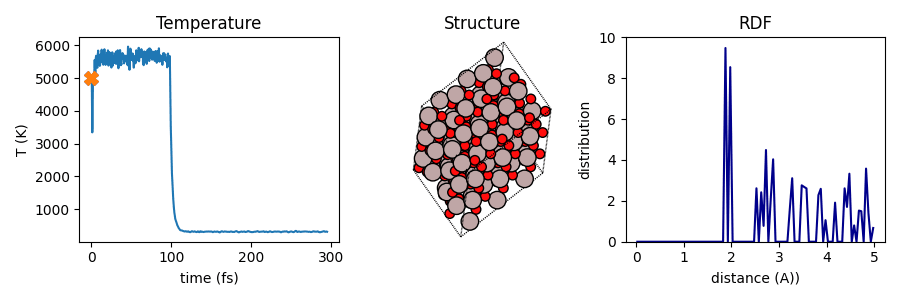

In [22]:
from IPython.display import Image, display

display(Image(filename='ani_sio2_2k.gif'))


SiO2

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


/usr/local/lib/python3.12/dist-packages/jarvis/analysis/structure/spacegroup.py:315: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  n = self._dataset["number"]
<timed exec>:12: FutureWarning: Please use atoms.calc = calc
/usr/local/lib/python3.12/dist-packages/ase/md/md.py:54: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


Streaming output truncated to the last 5000 lines.
        (2): SiLU()
      )
    )
  )
  (angle_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=40, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
  )
  (alignn_layers): ModuleList(
    (0-1): 2 x ALIGNNConv(
      (node_update): EdgeGatedGraphConv(
        (src_gate): Linear(in_features=64, out_features=64, bias=True)
        (dst_gate): Linear(in_features=64, out_features=64, bias=True)
        (edge_gate): Linear(in_features=64, out_features=64, bias=True)
        (bn_edges): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (src_update): Linear(in_features=64,

MovieWriter imagemagick unavailable; using Pillow instead.


Time taken 1150.2220766544342
System
1.0
7.40589 -12.82737 0.0
7.40589 12.82737 0.0
0.0 0.0 10.89862
Si O 
54 108 
direct
0.18366024016583368 -0.02011037447250126 0.37314321236801967 Si
0.1569642448478871 0.027596840811592898 0.8131100823707309 Si
0.13012913726843994 0.33431183300506606 0.31216260723918043 Si
0.15913140273256604 0.36115608164927077 0.8471666466287198 Si
0.15650617164826694 0.6741713091722352 0.35019668040805574 Si
0.15717382856703002 0.6800935710434651 0.8333770847665284 Si
0.5055030688045568 -0.0036203965418056586 0.3323300077226862 Si
0.5279145233404067 -0.01226660026601935 0.8682717266885158 Si
0.49260936376526376 0.3258332812146646 0.339860699558418 Si
0.5065788437512272 0.33214282908524995 0.8128420408038509 Si
0.516571001245722 0.661529145001636 0.33892861548192776 Si
0.4757258552086346 0.6894420816518282 0.8126041720018806 Si
0.85221341904669 0.013060503352156175 0.35165958312168083 Si
0.8666956217062192 0.018435757092731125 0.8435624038989336 Si
0.8163284064112

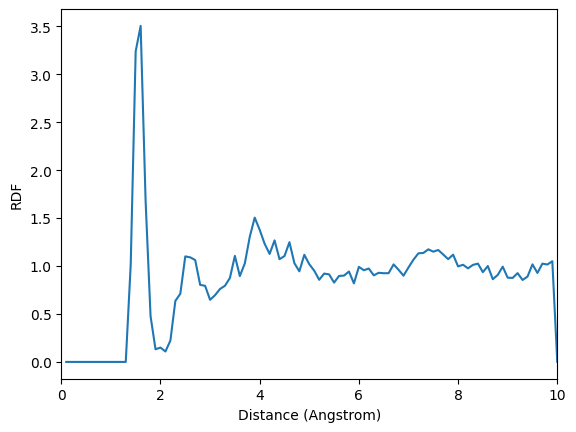

CPU times: user 20min 11s, sys: 13min 9s, total: 33min 20s
Wall time: 19min 46s


In [23]:
%%time
def get_atoms(jid):
    dat = get_jid_data(jid=jid, dataset="dft_3d")
    atoms= Atoms.from_dict(dat["atoms"]).get_conventional_atoms
    dim = get_supercell_dims(atoms,enforce_c_size=10)
    atoms = atoms.make_supercell([dim[0], dim[1], dim[2]])
    print(atoms)
    return atoms.ase_converter()

jid='JVASP-41'
#jid='JVASP-1002'
atoms = get_atoms(jid)
atoms.set_calculator(calc)
t1=time.time()

dt = 1 * units.fs

temp0, nsteps0 = 5500, 1000
temp1, nsteps1 = 300, 2000
taut = 20*units.fs

MaxwellBoltzmannDistribution(atoms, temp0*units.kB)
dyn = NVTBerendsen(atoms, dt, temp0, taut=taut, trajectory='md.traj')
def myprint():
    print(f'time={dyn.get_time() / units.fs: 5.0f} fs ' + \
          f'T={atoms.get_temperature(): 3.0f} K')
dyn.attach(myprint, interval=20)
dyn.run(nsteps0)

#Raise the temperature
dyn.set_temperature(temp1)
dyn.run(nsteps1)


traj =  Trajectory('md.traj')

fig, ax = plt.subplots(1, 3, figsize=(9,3), tight_layout=True)

t = np.arange(nsteps0+nsteps1+1) * dt
temp = [atoms.get_temperature() for atoms in traj]

nframes = 20



t2=time.time()
print('Time taken', t2-t1)
def update(iframe):
    idx = int((nsteps0+nsteps1)*iframe/nframes)

    ax[0].clear()
    ax[0].set_title('Temperature')
    ax[0].set_xlabel('time (fs)')
    ax[0].set_ylabel('T (K)')
    ax[0].plot(t, temp)
    ax[0].plot(t[idx], temp[idx], marker='X', markersize=10)

    ax[1].clear()
    ax[1].set_title('Structure')
    ax[1].axis('off')
    plot_atoms(traj[idx], ax=ax[1], rotation='45x,45y')

    distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]
    ax[2].clear()
    ax[2].set_title('RDF')
    ax[2].set_ylim((0,10))
    ax[2].set_xlabel('distance (A))')
    ax[2].set_ylabel('distribution')
    ax[2].plot(distance, distribution, color='darkblue')
ani = FuncAnimation(fig, update, np.arange(nframes), blit=False, interval=250.)
ani.save('ani_sio2_2k.gif', writer="imagemagick")
plt.close()

traj = Trajectory('md.traj')
atoms=ase_to_atoms(traj[-1])
print(atoms)
dists=[]
for i in atoms.get_all_neighbors(r=10):
    for j in i:
      dists.append(j[2])
dists=np.array(dists)
hist, bins = np.histogram(dists, bins=np.arange(0.1, 10.2, 0.1))
number_density = atoms.num_atoms / atoms.volume
shell_vol = (
            4.0
            / 3.0
            * np.pi
            * (np.power(bins[1:], 3) - np.power(bins[:-1], 3))
        )
rdf = (
            hist / shell_vol / number_density / atoms.num_atoms
        )
plt.plot(bins[:-1], rdf)
plt.xlim([0,10])
plt.xlabel('Distance (Angstrom)')
plt.ylabel('RDF')
# plt.savefig('rdf.png')
# plt.close()
plt.show()


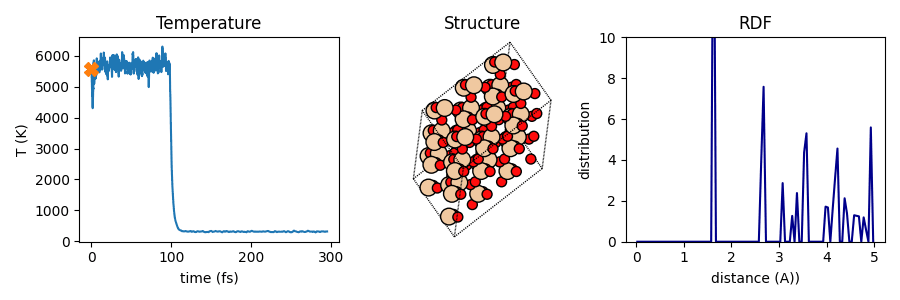

In [24]:
from IPython.display import Image, display

display(Image(filename='ani_sio2_2k.gif'))
